# Qiskit Installation

In [8]:
pip install qiskit

# Pylatexenc Installation
It converts LaTeX markup to Unicode text and vice versa.

In [9]:
pip install pylatexenc

# Matplotlib Installation

In [10]:
pip install matplotlib

# Imports
This section imports all the libraries required to run the project.

In [11]:
## Imports
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

from collections import defaultdict
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import Optimize1qGates, CommutativeCancellation
from joblib import Parallel, delayed

Here to ensure that all random operations produce the same results across runs by fixing a global random seed.

In [12]:
# ============================================================
# 0. Reproducibility
# ============================================================

def set_random_seeds(seed: int = 42):
    """Configure toutes les graines aléatoires pour la reproductibilité."""
    np.random.seed(seed)
    random.seed(seed)
    plt.rcParams['axes.prop_cycle'] = plt.cycler('color', plt.cm.Set1.colors)
    print(f"✅ Seeds configurées : {seed}")

We define the `Individual` class, which represents a single candidate solution in the genetic algorithm. Each individual carries a chromosome (a quantum circuit) and a fitness score measuring how close it is to the target.

In [13]:
# ============================================================
# 1. Individual
# ============================================================

class Individual:
    """Individu portant un chromosome et une valeur de fitness scalaire."""

    def __init__(self, chromosome, fitness: float = None):
        self.chromosome = chromosome
        self.fitness    = fitness          # float in [0, 1]

# ***Step 1 : Quantum Circuit Generation***
This section defines the building blocks of the genetic algorithm's search space: the **gate set**, and the functions that randomly generate **genes**, **chromosomes**, and **populations** of quantum circuits.
## Gate Set
A fixed dictionary `QUANTUM_GATES` defines all allowed quantum gates, each tagged with two properties:
- `control` : whether the gate requires one or more control qubits (e.g. `CX`, `CZ`, `CCX`).
- `rotation` : whether the gate requires a rotation angle (e.g. `RX`, `RY`, `RZ`).

## Gene Structure
A **gene** is the smallest unit of a circuit, encoded as a list of 4 fields:
`[target_qubit, gate, control_qubit, angle]`
- `target_qubit` : the qubit the gate acts on.
- `gate` : the gate name, randomly chosen from `QUANTUM_GATES`.
- `control_qubit` : one control qubit (or a list of two for `CCX`), or `None` if not needed.
- `angle` : a random rotation angle in `[0, 2π]` for rotation gates, or `None` otherwise.

## Chromosome & Population
- A **chromosome** is a sequence of `num_genes` genes, representing a full quantum circuit.
- A **population** is a collection of `pop_size` chromosomes, forming the initial set of candidate solutions for the genetic algorithm.

In [14]:
# ============================================================
# 2. Gate set & circuit generation
# ============================================================

QUANTUM_GATES = {
    "H":   {"control": False, "rotation": False},
    "X":   {"control": False, "rotation": False},
    "Y":   {"control": False, "rotation": False},
    "Z":   {"control": False, "rotation": False},
    "CX":  {"control": True,  "rotation": False},
    "CZ":  {"control": True,  "rotation": False},   # ← added
    "CCX": {"control": True,  "rotation": False},   # ← added (Toffoli, needs 2 controls)
    "RX":  {"control": False, "rotation": True},
    "RY":  {"control": False, "rotation": True},
    "RZ":  {"control": False, "rotation": True},
}


def generate_gene(num_qubits: int) -> list:
    """
    Génère un gène aléatoire [target, gate, control, angle].
    CCX requiert 2 qubits de contrôle distincts du target.
    """
    target_qubit  = np.random.randint(num_qubits)
    gate          = np.random.choice(list(QUANTUM_GATES.keys()))
    control_qubit = None
    angle         = None

    if gate == "CCX":
        # 2 qubits de contrôle distincts du target
        possible = list(set(range(num_qubits)) - {target_qubit})
        if len(possible) < 2:                        # fallback si trop peu de qubits
            gate = "CX"
            control_qubit = possible[0] if possible else (target_qubit + 1) % num_qubits
        else:
            control_qubit = np.random.choice(possible, size=2, replace=False).tolist()
    elif QUANTUM_GATES[gate]["control"]:
        control_qubit = np.random.randint(num_qubits)
        while control_qubit == target_qubit:
            control_qubit = np.random.randint(num_qubits)

    if QUANTUM_GATES[gate]["rotation"]:
        angle = np.random.uniform(0, 2 * np.pi)

    return [target_qubit, gate, control_qubit, angle]


def generate_chromosome(num_qubits: int, num_genes: int) -> list:
    return [generate_gene(num_qubits) for _ in range(num_genes)]


def generate_population(pop_size: int, num_qubits: int, num_genes: int) -> list:
    return [generate_chromosome(num_qubits, num_genes) for _ in range(pop_size)]


# ***Step 2 : Chromosome to Quantum Circuit Conversion***
This section defines the function that translates a **chromosome** (a list of genes) into an executable **Qiskit quantum circuit**, by mapping each gene to its corresponding quantum gate operation.

In [15]:
def create_quantum_circuit(chromosome: list, num_qubits: int) -> QuantumCircuit:
    """Transforme un chromosome en circuit quantique Qiskit."""
    circuit = QuantumCircuit(num_qubits)
    for gene in chromosome:
        target, gate, control, angle = gene
        if gate in ["H", "X", "Y", "Z"]:
            getattr(circuit, gate.lower())(target)
        elif gate == "CX":
            circuit.cx(control, target)
        elif gate == "CZ":
            circuit.cz(control, target)
        elif gate == "CCX":
            if isinstance(control, list) and len(control) == 2:
                circuit.ccx(control[0], control[1], target)
        elif gate in ["RX", "RY", "RZ"]:
            getattr(circuit, gate.lower())(angle, target)
    return circuit


# ***Step 3 : Fitness Evaluation***
This section defines how the quality of each individual is measured. The fitness score is based on **quantum fidelity** — how closely a candidate circuit's unitary matrix matches the target unitary. The evaluation is run in **parallel** across the entire population for efficiency.

## Fidelity Formula
The fidelity between the candidate unitary `U` and the target unitary `U_target` is computed as:

$$F = \frac{|\text{Tr}(U \cdot U_{\text{target}}^\dagger)|}{2^n}$$

Where `n` is the number of qubits. This metric is **global-phase invariant** and returns a value in `[0, 1]`, where `1` means a perfect match.

In [16]:
# ============================================================
# 3. Fitness
# ============================================================

def compute_fidelity(circuit: QuantumCircuit, target_unitary: np.ndarray) -> float:
    """F = |Tr(U_candidate @ U_target†)| / 2^n — invariant à la phase globale."""
    candidate_unitary = Operator(circuit).data
    target_dagger     = np.conj(target_unitary).T
    trace_value       = np.trace(np.dot(candidate_unitary, target_dagger))
    return np.abs(trace_value) / (2 ** circuit.num_qubits)


def evaluate_individual(chromosome: list, num_qubits: int,
                         target_unitary: np.ndarray) -> float:
    circuit = create_quantum_circuit(chromosome, num_qubits)
    return compute_fidelity(circuit, target_unitary)


def parallel_evaluation(chromosomes: list, num_qubits: int,
                         target_unitary: np.ndarray) -> list:
    """Évaluation parallèle de la population (joblib)."""
    return Parallel(n_jobs=-1)(
        delayed(evaluate_individual)(c, num_qubits, target_unitary)
        for c in chromosomes
    )


# ***Step 4 : Selection***
This section defines three **selection strategies** used to choose which individuals reproduce in each generation. Each method offers a different trade-off between selection pressure and population diversity.


 **Tournament Selection** : randomly picks a small group and selects the fittest — fast and effective for maintaining selection pressure.

In [17]:
# ============================================================
# 4. Tournament Selection
# ============================================================

def tournament_selection(population: list, tournament_size: int = 3) -> Individual:
    """Sélection par tournoi — rapide, bonne pression sélective."""
    candidates = random.sample(population, min(tournament_size, len(population)))
    return max(candidates, key=lambda ind: ind.fitness)

**Roulette Wheel Selection** : assigns each individual a selection probability proportional to its fitness — fitter individuals are more likely to be chosen, but weaker ones still have a chance.

In [18]:
def roulette_wheel_selection(population: list, num_selected: int) -> list:
    """
    Sélection par roulette proportionnelle à la fitness.
    Ajoute un petit epsilon pour éviter les probabilités nulles.
    """
    fitnesses = np.array([ind.fitness for ind in population]) + 1e-9
    probs     = fitnesses / fitnesses.sum()
    indices   = np.random.choice(len(population), size=num_selected, p=probs)
    return [population[i] for i in indices]

 **Rank Selection** : selects based on rank order rather than raw fitness values — reduces the dominance of extremely fit individuals and helps preserve diversity.

In [19]:
def rank_selection(population: list, num_selected: int) -> list:
    """
    Sélection par rang — atténue la dominance des très bons individus.
    Le meilleur a le rang N, le pire a le rang 1.
    """
    sorted_pop = sorted(population, key=lambda ind: ind.fitness)
    ranks      = np.arange(1, len(sorted_pop) + 1, dtype=float)
    probs      = ranks / ranks.sum()
    indices    = np.random.choice(len(sorted_pop), size=num_selected, p=probs)
    return [sorted_pop[i] for i in indices]


# ***Step 5 : Crossover***
This section defines the **crossover operator**, which combines two parent chromosomes to produce two offspring. It mimics biological recombination, allowing the algorithm to mix and inherit good gene sequences from both parents.

## Method
A **single-point crossover** is used: a random cut point is chosen along the shorter chromosome, and the two parents swap their tails at that point, producing two new child chromosomes.

In [20]:
# ============================================================
# 5. Crossover
# ============================================================

def crossover(parent1: list, parent2: list):
    """Croisement un-point."""
    min_len = min(len(parent1), len(parent2))
    if min_len < 2:
        return copy.deepcopy(parent1), copy.deepcopy(parent2)
    cut = np.random.randint(1, min_len)
    return parent1[:cut] + parent2[cut:], parent2[:cut] + parent1[cut:]

# ***Step 6 : Mutation***
This section defines the **mutation operators** that introduce random changes into chromosomes to explore new regions of the search space. Mutation is enhanced with **Simulated Annealing (SA)** acceptance, allowing occasionally worse solutions to be accepted early in the search to avoid local optima.
## Simulated Annealing Acceptance
When a mutation decreases fitness, it is not automatically rejected. Instead, it is accepted with a probability based on the SA criterion:

$$P(\text{accept}) = e^{\Delta F / T}$$

Where `ΔF` is the fitness change (negative) and `T` is the current temperature, which decreases over generations as `T = T_0 \times r^g`, cooling the search over time.

## Mutation Pipeline
The full `mutate()` function applies three successive operations:

- **Gene Mutation** : randomly replaces up to `max_mutations` genes with newly generated ones, subject to SA acceptance.
- **Structural Mutation** : randomly adds a new gate or removes an existing one from the chromosome, subject to SA acceptance.
- **Rotation Angle Update** : fine-tunes the rotation angles of existing `RX`, `RY`, `RZ` gates using local gradient-free optimization.

In [21]:
# ============================================================
# 6. Mutation — enhanced with simulated annealing
# ============================================================

def _sa_accept(delta: float, temperature: float) -> bool:
    """Critère d'acceptation du recuit simulé : exp(Δ/T) > U(0,1)."""
    if temperature <= 0:
        return False
    return np.random.rand() < np.exp(delta / temperature)


def mutate_genes(chromosome: list, num_qubits: int,
                  mutation_rate: float, max_mutations: int,
                  target_unitary: np.ndarray, num_qubits_circ: int,
                  generation: int, initial_temp: float,
                  cooling_rate: float) -> list:
    """
    Mutation classique : remplace aléatoirement jusqu'à max_mutations gènes.
    Acceptation SA si la mutation dégrade la fitness.
    """
    if np.random.rand() > mutation_rate:
        return chromosome

    original         = copy.deepcopy(chromosome)
    original_fitness = evaluate_individual(original, num_qubits_circ, target_unitary)

    num_genes    = len(chromosome)
    n_mut        = np.random.randint(1, min(max_mutations, num_genes) + 1)
    indices      = np.random.choice(num_genes, size=n_mut, replace=False)
    mutated      = copy.deepcopy(chromosome)

    for idx in indices:
        mutated[idx] = generate_gene(num_qubits)

    mutated_fitness = evaluate_individual(mutated, num_qubits_circ, target_unitary)

    if mutated_fitness >= original_fitness:
        return mutated

    T     = initial_temp * (cooling_rate ** generation)
    delta = mutated_fitness - original_fitness
    return mutated if _sa_accept(delta, T) else original


def mutate_structure(chromosome: list, num_qubits: int,
                      target_unitary: np.ndarray,
                      generation: int, initial_temp: float,
                      cooling_rate: float) -> list:
    """
    Mutation structurelle : ajoute ou supprime une porte.
    Acceptation SA si la mutation dégrade la fitness.
    """
    original         = copy.deepcopy(chromosome)
    original_fitness = evaluate_individual(original, num_qubits, target_unitary)
    mutated          = copy.deepcopy(chromosome)

    if np.random.rand() < 0.5 and len(mutated) > 1:
        del mutated[np.random.randint(len(mutated))]
    else:
        idx = np.random.randint(len(mutated) + 1)
        mutated.insert(idx, generate_gene(num_qubits))

    mutated_fitness = evaluate_individual(mutated, num_qubits, target_unitary)

    if mutated_fitness >= original_fitness:
        return mutated

    T     = initial_temp * (cooling_rate ** generation)
    delta = mutated_fitness - original_fitness
    return mutated if _sa_accept(delta, T) else original


def mutate(chromosome: list, num_qubits: int,
           mutation_rate: float, max_mutations: int,
           target_unitary: np.ndarray,
           generation: int, initial_temp: float,
           cooling_rate: float) -> list:
    """
    Pipeline de mutation complet :
      1. Mutation classique (substitution de gènes) avec SA
      2. Mutation structurelle (ajout/suppression) avec SA
      3. Optimisation locale des angles de rotation
    """
    chromosome = mutate_genes(
        chromosome, num_qubits, mutation_rate, max_mutations,
        target_unitary, num_qubits, generation, initial_temp, cooling_rate
    )
    chromosome = mutate_structure(
        chromosome, num_qubits, target_unitary,
        generation, initial_temp, cooling_rate
    )
    chromosome = update_rotation_angles(
        chromosome, num_qubits, target_unitary,
        eta_range=[0.01, 0.1, 0.5], delta=0.1
    )
    return chromosome


# ***Local Angle Optimization***
This section defines a **local gradient-based optimizer** that fine-tunes the rotation angles of `RX`, `RY`, and `RZ` gates in a chromosome. Rather than relying solely on random mutation, this step performs a targeted numerical refinement to improve fitness without changing the circuit structure.

## Method
For each rotation angle `θ` in the chromosome, the gradient is estimated using **central finite differences**:

$$\nabla F(\theta) \approx \frac{F(\theta + \delta) - F(\theta - \delta)}{2\delta}$$

The angle is then updated as:

$$\theta_{\text{new}} = \theta + \eta \cdot \nabla F(\theta)$$

Where `η` is the learning rate, tested over a range of values (`eta_range`). Only the update that yields the highest fitness improvement is kept.

In [22]:
# ============================================================
# 7. Local angle optimisation (gradient-based)
# ============================================================

def update_rotation_angles(chromosome: list, num_qubits: int,
                            target_unitary: np.ndarray,
                            eta_range: list = None,
                            delta: float = 0.1) -> list:
    """
    Raffine localement les angles θ des portes RX/RY/RZ par descente de
    gradient par différences finies centrées.

    Pour chaque angle θ :
        gradient ≈ (F(θ+δ) − F(θ−δ)) / (2δ)
        θ_new     = θ + η * gradient     (meilleur η parmi eta_range)
    """
    if eta_range is None:
        eta_range = [0.01, 0.1, 0.5]

    best = copy.deepcopy(chromosome)

    for i, gene in enumerate(best):
        if gene[1] not in ["RX", "RY", "RZ"] or gene[3] is None:
            continue

        theta        = gene[3]
        best_fitness = evaluate_individual(best, num_qubits, target_unitary)
        best_theta   = theta

        for eta in eta_range:
            # F(θ + δ)
            best[i][3] = theta + delta
            F_plus     = evaluate_individual(best, num_qubits, target_unitary)
            # F(θ − δ)
            best[i][3] = theta - delta
            F_minus    = evaluate_individual(best, num_qubits, target_unitary)

            gradient  = (F_plus - F_minus) / (2 * delta)
            new_theta = theta + eta * gradient
            best[i][3] = new_theta

            new_fitness = evaluate_individual(best, num_qubits, target_unitary)
            if new_fitness > best_fitness:
                best_fitness = new_fitness
                best_theta   = new_theta

        best[i][3] = best_theta   # keep the best angle found

    return best


# ***Dynamic Mutation Rate***
This section defines an **adaptive mutation rate** that automatically adjusts throughout the run to balance exploration and exploitation. Instead of using a fixed mutation rate, the algorithm increases it when the population stagnates and gradually decreases it otherwise as the search converges.

## Adaptation Rules
- **Stagnation detected** (no improvement for `stagnation_threshold` generations) → the mutation rate is **doubled** to escape local optima and encourage exploration.
- **Normal progress** → the mutation rate **decays progressively** as generations advance, shifting focus toward exploitation of good solutions.

In [23]:
# ============================================================
# 8. Dynamic mutation rate
# ============================================================

def adjust_mutation_rate(base_rate: float, generation: int,
                          max_generations: int, stagnation_counter: int,
                          stagnation_threshold: int = 20) -> float:
    """
    Taux adaptatif :
      • stagnation ≥ threshold  →  doublement (exploration)
      • sinon                   →  décroissance progressive (exploitation)
    """
    if stagnation_counter >= stagnation_threshold:
        return min(1.0, base_rate * 2.0)
    decay = 0.5 * (1.0 - generation / max_generations)
    return max(0.01, base_rate * (1.0 + decay))

# ***Step 7 : Circuit Post-Processing Pipeline***
This section defines a **circuit compression pipeline** that simplifies quantum circuits after evolution, reducing gate count without changing the circuit's logical behavior. Shorter, cleaner circuits are easier to execute on real quantum hardware and less prone to noise.
## Pipeline Steps
The full `compress_circuit()` function applies four successive simplification passes:

1. **Consecutive Gate Simplification** : applies local algebraic rules on pairs of adjacent gates on the same qubit, including:
   - Cancelling involutive gates (`X·X = I`, `H·H = I`, `CX·CX = I`, etc.)
   - Replacing `S·S → Z`, `T·T → S`, `T⁴ → Z`
   - Cancelling rotation pairs where `θ + φ ≈ 0`

2. **Rotation Merging** : merges consecutive rotations of the same type (`RX`, `RY`, `RZ`) on the same qubit into a single rotation with the summed angle.

3. **Negligible Rotation Removal** : removes any rotation gate whose angle is smaller than a threshold (default `1e-4`), as it is effectively an identity operation.

4. **Qiskit Transpiler Passes** : applies Qiskit's built-in `Optimize1qGates` and `CommutativeCancellation` passes for further hardware-level optimization.

In [24]:
# ============================================================
# 9. Circuit post-processing pipeline
# ============================================================

def simplify_consecutive_gates(circuit: QuantumCircuit) -> QuantumCircuit:
    """
    Règles locales sur paires de portes consécutives :
      1. U·U = I  pour U ∈ {x,y,z,h,cx,cz}  (mêmes qubits)
      2. s·s  → z
      3. t·t  → s
      4. t⁴   → z
      5. rx/ry/rz(θ) · rx/ry/rz(φ) → annulation si θ+φ ≈ 0
    """
    new_circ = QuantumCircuit(circuit.num_qubits)
    i, n     = 0, len(circuit.data)

    def same_q(a, b):
        return tuple(a) == tuple(b)

    while i < n:
        instr_i = circuit.data[i]
        gi      = instr_i.operation
        qi      = instr_i.qubits

        if i == n - 1:
            new_circ.append(gi, qi)
            break

        instr_j = circuit.data[i + 1]
        gj      = instr_j.operation
        qj      = instr_j.qubits

        # Rule 1 : involutive gates
        if gi.name == gj.name and same_q(qi, qj) and gi.name in {'x','y','z','h','cx','cz'}:
            i += 2; continue

        # Rule 2 : s·s → z
        if gi.name == 's' and gj.name == 's' and same_q(qi, qj):
            new_circ.z(qi[0]); i += 2; continue

        # Rule 3 : t·t → s
        if gi.name == 't' and gj.name == 't' and same_q(qi, qj):
            new_circ.s(qi[0]); i += 2; continue

        # Rule 4 : t⁴ → z
        if gi.name == 't' and i + 3 < n:
            ok = all(circuit.data[i+k].operation.name == 't' and
                     same_q(circuit.data[i+k].qubits, qi) for k in range(1, 4))
            if ok:
                new_circ.z(qi[0]); i += 4; continue

        # Rule 5 : rotation cancellation
        if gi.name == gj.name and gi.name in {'rx','ry','rz'} and same_q(qi, qj):
            theta, phi = float(gi.params[0]), float(gj.params[0])
            if np.isclose((theta + phi + np.pi) % (2 * np.pi) - np.pi, 0.0, atol=1e-3):
                i += 2; continue

        new_circ.append(gi, qi)
        i += 1

    return new_circ

def merge_rotations(circuit: QuantumCircuit) -> QuantumCircuit:
    """Fusionne les rotations successives du même type sur le même qubit."""
    new_circ = QuantumCircuit(circuit.num_qubits)
    i = 0
    while i < len(circuit.data):
        instr = circuit.data[i]
        gate  = instr.operation
        qargs = instr.qubits

        if gate.name in ('rx', 'ry', 'rz'):
            angle = gate.params[0]
            j     = i + 1
            while j < len(circuit.data):
                nxt = circuit.data[j]
                if nxt.operation.name == gate.name and nxt.qubits == qargs:
                    angle += nxt.operation.params[0]; j += 1
                else:
                    break
            qidx = circuit.qubits.index(qargs[0])
            getattr(new_circ, gate.name)(angle, qidx)
            i = j
        else:
            qidx = [circuit.qubits.index(q) for q in qargs]
            new_circ.append(gate, qidx)
            i += 1

    return new_circ


def remove_negligible_rotations(circuit: QuantumCircuit,
                                  threshold: float = 1e-4) -> QuantumCircuit:
    """Supprime les rotations dont l'angle est négligeable (≈ identité)."""
    new_circ = QuantumCircuit(circuit.num_qubits)
    for instr in circuit.data:
        gate  = instr.operation
        qargs = instr.qubits
        if gate.name in ('rx', 'ry', 'rz') and abs(gate.params[0]) < threshold:
            continue
        qidx = [circuit.qubits.index(q) for q in qargs]
        new_circ.append(gate, qidx)
    return new_circ


def qiskit_transpiler_passes(circuit: QuantumCircuit) -> QuantumCircuit:
    """Passe Qiskit : Optimize1qGates + CommutativeCancellation."""
    pm = PassManager([Optimize1qGates(), CommutativeCancellation()])
    return pm.run(circuit)


def compress_circuit(circuit: QuantumCircuit) -> QuantumCircuit:
    """
    Pipeline complet de compression :
      1. Simplification des paires consécutives
      2. Fusion des rotations
      3. Suppression des rotations négligeables
      4. Passes Qiskit
    """
    c = simplify_consecutive_gates(circuit)
    c = merge_rotations(c)
    c = remove_negligible_rotations(c)
    c = qiskit_transpiler_passes(c)
    return c


# ***Main Genetic Algorithm***
This section implements the **core genetic algorithm loop** that drives the entire optimization process. It orchestrates all previously defined components — selection, crossover, mutation, and evaluation — across multiple generations to evolve a population of quantum circuits toward the target unitary.
## Algorithm Flow
Each generation runs the following steps:

1. **Fitness Tracking** : records the best, mean, and standard deviation of fitness across the population for monitoring convergence.
2. **Stagnation Detection** : if no improvement is observed for `stagnation_thr` consecutive generations, the mutation rate is reset and boosted to escape local optima.
3. **Dynamic Mutation Rate** : calls `adjust_mutation_rate()` each generation to adapt the mutation intensity based on progress.
4. **Elitism** : the top `elitism_ratio` of individuals are carried over unchanged to the next generation, preserving the best solutions found so far.
5. **Parent Selection** : supports three strategies, controlled by `selection_mode`: `"roulette"`, `"rank"`, or `"tournament"`.
6. **Crossover** : pairs of parents are recombined with probability `crossover_rate` using single-point crossover.
7. **Mutation** : each offspring goes through the full mutation pipeline (gene mutation + structural mutation + angle optimization), all guided by simulated annealing.
8. **Survivor Selection** : the next generation is formed by keeping the elites and filling the rest via roulette wheel selection from the combined pool of parents and offspring.

## Output
At the end of all generations, the best individual is selected, its circuit is compressed via `compress_circuit()`, and the fidelity before and after compression is reported. The function returns the best individual, the compressed circuit, and the full fitness history.

In [25]:
# ============================================================
# 10. Main GA
# ============================================================

def single_objective_genetic_algorithm(
    num_qubits:      int,
    num_genes:       int,
    pop_size:        int,
    generations:     int,
    target_unitary:  np.ndarray,
    mutation_rate:   float = 0.1,
    max_mutations:   int   = 2,
    crossover_rate:  float = 0.9,
    elitism_ratio:   float = 0.1,
    initial_temp:    float = 1.0,
    cooling_rate:    float = 0.95,
    stagnation_thr:  int   = 20,
    selection_mode:  str   = "roulette",   # "roulette" | "rank" | "tournament"
):

    # ---- init ----
    elite_count      = max(1, int(elitism_ratio * pop_size))
    chromosomes      = generate_population(pop_size, num_qubits, num_genes)
    fitness_vals     = parallel_evaluation(chromosomes, num_qubits, target_unitary)
    population       = [Individual(c, f) for c, f in zip(chromosomes, fitness_vals)]

    best_overall_fitness = -1.0
    stagnation_counter   = 0
    history              = {"best": [], "mean": [], "std": []}
    current_mut_rate     = mutation_rate

    for gen in range(generations):

        fitnesses = [ind.fitness for ind in population]
        best_fit  = max(fitnesses)
        mean_fit  = float(np.mean(fitnesses))
        std_fit   = float(np.std(fitnesses))

        history["best"].append(best_fit)
        history["mean"].append(mean_fit)
        history["std"].append(std_fit)

        print(f"Génération {gen+1:3d}/{generations} | "
              f"Best={best_fit:.4f}  Mean={mean_fit:.4f}  "
              f"Std={std_fit:.4f}  MutRate={current_mut_rate:.3f}")

        # ---- stagnation tracking ----
        if best_fit > best_overall_fitness + 1e-6:
            best_overall_fitness = best_fit
            stagnation_counter   = 0
            current_mut_rate     = mutation_rate          # reset
        else:
            stagnation_counter  += 1

        # ---- dynamic mutation rate ----
        current_mut_rate = adjust_mutation_rate(
            base_rate           = current_mut_rate,
            generation          = gen,
            max_generations     = generations,
            stagnation_counter  = stagnation_counter,
            stagnation_threshold= stagnation_thr,
        )

        # ---- elitism : copy top individuals unchanged ----
        population.sort(key=lambda ind: ind.fitness, reverse=True)
        elites   = population[:elite_count]
        offspring = list(elites)

        # ---- selection pool for crossover ----
        non_elites = population[elite_count:]

        while len(offspring) < pop_size:
            # select parents according to chosen strategy
            if selection_mode == "roulette":
                parents = roulette_wheel_selection(population, 2)
                p1, p2  = parents[0], parents[1]
            elif selection_mode == "rank":
                parents = rank_selection(population, 2)
                p1, p2  = parents[0], parents[1]
            else:   # tournament (default fallback)
                p1 = tournament_selection(population)
                p2 = tournament_selection(population)

            # crossover
            if np.random.rand() < crossover_rate:
                c1_chr, c2_chr = crossover(p1.chromosome, p2.chromosome)
            else:
                c1_chr = copy.deepcopy(p1.chromosome)
                c2_chr = copy.deepcopy(p2.chromosome)

            # full mutation pipeline (SA + structural + angle optim)
            c1_chr = mutate(c1_chr, num_qubits, current_mut_rate,
                            max_mutations, target_unitary,
                            gen, initial_temp, cooling_rate)
            c2_chr = mutate(c2_chr, num_qubits, current_mut_rate,
                            max_mutations, target_unitary,
                            gen, initial_temp, cooling_rate)

            c1_fit = evaluate_individual(c1_chr, num_qubits, target_unitary)
            c2_fit = evaluate_individual(c2_chr, num_qubits, target_unitary)

            offspring.append(Individual(c1_chr, c1_fit))
            if len(offspring) < pop_size:
                offspring.append(Individual(c2_chr, c2_fit))

        # ---- survivor selection : elites + roulette on the rest ----
        combined     = population + offspring
        combined.sort(key=lambda ind: ind.fitness, reverse=True)
        new_elites   = combined[:elite_count]
        remaining    = combined[elite_count:]
        selected_rest= roulette_wheel_selection(remaining, pop_size - elite_count)
        population   = new_elites + selected_rest

    # ---- final best ----
    best_individual = max(population, key=lambda ind: ind.fitness)
    best_circuit    = create_quantum_circuit(best_individual.chromosome, num_qubits)
    best_compressed = compress_circuit(best_circuit)

    f_before = compute_fidelity(best_circuit,    target_unitary)
    f_after  = compute_fidelity(best_compressed, target_unitary)
    print(f"\n🔧 Fidélité avant compression : {f_before:.4f}")
    print(f"🔧 Fidélité après compression : {f_after:.4f}")

    return best_individual, best_compressed, history

In [26]:
# ============================================================
# 11. Target circuit
# ============================================================

def create_target_circuit(num_qubits: int = 4, num_layers: int = 4):
    """Circuit cible — identique à la version multi-objectif."""
    qc = QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        qc.h(i)
    for _ in range(num_layers):
        for j in range(num_qubits - 1):
            qc.cx(j, j + 1)
    for i in range(num_qubits):
        qc.rz((i + 1) * np.pi / 14, i)

    print("🎯 Circuit Cible :")
    fig, ax = plt.subplots(figsize=(6, 3))
    qc.draw(output='mpl', ax=ax, fold=20)
    plt.tight_layout()
    plt.show()
    return Operator(qc).data

# ***Visualization***
This section defines all plotting utilities used to analyze and interpret the results of the genetic algorithm. It covers convergence monitoring, gate composition comparison, circuit complexity metrics, and direct circuit rendering.

## Plots
- **Convergence Curve** (`plot_convergence`) : plots the best and mean fitness over generations, with a ±1 standard deviation band, giving a clear picture of how the population evolved and whether the algorithm converged.
- **Gate Type Comparison** (`plot_gate_comparison`) : side-by-side bar chart comparing the gate composition of the target circuit, the optimized circuit, and the compressed circuit — useful for assessing how well the GA reproduced the target structure.
- **Depth & Gate Count** (`plot_depth_and_gate_count`) : two bar charts showing circuit depth and total gate count across the three circuits, highlighting the compression gain achieved by the post-processing pipeline.
- **Circuit Diagram** (`plot_best_circuit`) : renders the best circuit directly using Qiskit's built-in drawer, and prints a summary of its gate counts and depth.

In [27]:
# ============================================================
# 12. Visualisation
# ============================================================

def plot_convergence(history: dict):
    """Courbe de convergence : best / mean ± std."""
    gens = range(1, len(history["best"]) + 1)
    best = history["best"]
    mean = np.array(history["mean"])
    std  = np.array(history["std"])

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(gens, best, 'r-',  linewidth=2,   label='Meilleure fidélité')
    ax.plot(gens, mean, 'b--', linewidth=1.5, label='Fidélité moyenne')
    ax.fill_between(gens, mean - std, mean + std,
                    alpha=0.15, color='blue', label='±1 écart-type')
    ax.set_xlabel('Génération', fontsize=12)
    ax.set_ylabel('Fidélité',   fontsize=12)
    ax.set_title('Convergence du GA mono-objectif (amélioré)', fontsize=13)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_gate_comparison(target_circuit: QuantumCircuit,
                          optimized_circuit: QuantumCircuit,
                          compressed_circuit: QuantumCircuit):
    """Comparaison des portes : cible / optimisé / compressé."""
    def count(c): return defaultdict(int, c.count_ops())

    g_target = count(target_circuit)
    g_opt    = count(optimized_circuit)
    g_comp   = count(compressed_circuit)

    all_gates = sorted(set(g_target) | set(g_opt) | set(g_comp))
    x         = np.arange(len(all_gates))
    w         = 0.25

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(x - w,   [g_target[g] for g in all_gates], w, label='Circuit cible')
    ax.bar(x,       [g_opt[g]    for g in all_gates], w, label='Circuit optimisé')
    ax.bar(x + w,   [g_comp[g]   for g in all_gates], w, label='Après compression')
    ax.set_xticks(x)
    ax.set_xticklabels(all_gates)
    ax.set_ylabel("Occurrences")
    ax.set_title("Comparaison des types de portes")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_depth_and_gate_count(target_circuit: QuantumCircuit,
                               optimized_circuit: QuantumCircuit,
                               compressed_circuit: QuantumCircuit):
    """Barplot profondeur + nombre total de portes."""
    labels   = ['Cible', 'Optimisé', 'Compressé']
    depths   = [c.depth() for c in [target_circuit, optimized_circuit, compressed_circuit]]
    n_gates  = [sum(c.count_ops().values()) for c in
                [target_circuit, optimized_circuit, compressed_circuit]]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.bar(labels, depths,  color=['gray', 'steelblue', 'green'])
    ax1.set_title('Profondeur du circuit')
    ax1.set_ylabel('Profondeur')
    ax1.grid(True, alpha=0.3)

    ax2.bar(labels, n_gates, color=['gray', 'steelblue', 'green'])
    ax2.set_title('Nombre total de portes')
    ax2.set_ylabel('Portes')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_best_circuit(circuit: QuantumCircuit, label: str = "Meilleur circuit"):
    """Affiche un circuit Qiskit."""
    print(f"\n📐 {label}")
    print(f"   Portes    : {dict(circuit.count_ops())}")
    print(f"   Profondeur: {circuit.depth()}")
    fig, ax = plt.subplots(figsize=(9, 3))
    circuit.draw(output='mpl', ax=ax, fold=30)
    plt.tight_layout()
    plt.show()


# ***Entry Point***
This section is the **main execution block** that ties together all previously defined components. It configures the experiment parameters, defines the target quantum circuit, launches the genetic algorithm, and displays the final results and visualizations.
## Execution & Output
After the GA completes, the following are reported and plotted:
- Final best fitness (raw) and after compression.
- Convergence curve over generations.
- Raw and compressed best circuit diagrams.
- Gate type comparison and circuit depth/count bar charts.

✅ Seeds configurées : 29
🎯 Circuit Cible :


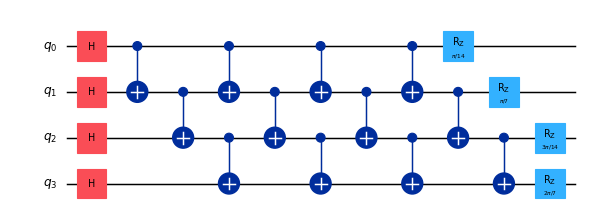


🚀 Démarrage de l'optimisation mono-objectif améliorée...
   4 qubits | 10 gènes | 100 individus | 50 générations
   Gate set : ['H', 'X', 'Y', 'Z', 'CX', 'CZ', 'CCX', 'RX', 'RY', 'RZ']
Génération   1/50 | Best=0.3024  Mean=0.0453  Std=0.0520  MutRate=0.100
Génération   2/50 | Best=0.3024  Mean=0.0928  Std=0.0591  MutRate=0.150
Génération   3/50 | Best=0.3263  Mean=0.1305  Std=0.0714  MutRate=0.224
Génération   4/50 | Best=0.3263  Mean=0.1715  Std=0.0745  MutRate=0.148
Génération   5/50 | Best=0.3263  Mean=0.1810  Std=0.0861  MutRate=0.218
Génération   6/50 | Best=0.3625  Mean=0.2207  Std=0.0841  MutRate=0.318
Génération   7/50 | Best=0.4859  Mean=0.2387  Std=0.0899  MutRate=0.145
Génération   8/50 | Best=0.4859  Mean=0.2617  Std=0.0890  MutRate=0.144
Génération   9/50 | Best=0.5006  Mean=0.2948  Std=0.0828  MutRate=0.206
Génération  10/50 | Best=0.5006  Mean=0.3157  Std=0.1092  MutRate=0.142
Génération  11/50 | Best=0.5142  Mean=0.3388  Std=0.1168  MutRate=0.200
Génération  12/50 | Be

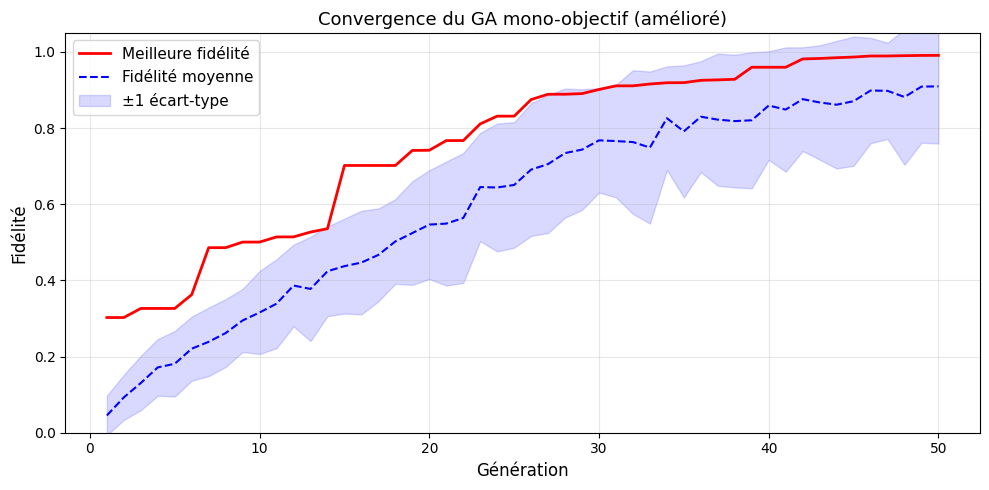


📐 Circuit optimisé (brut)
   Portes    : {'ry': 4, 'rz': 3, 'cx': 3, 'h': 2, 'rx': 1, 'cz': 1}
   Profondeur: 6


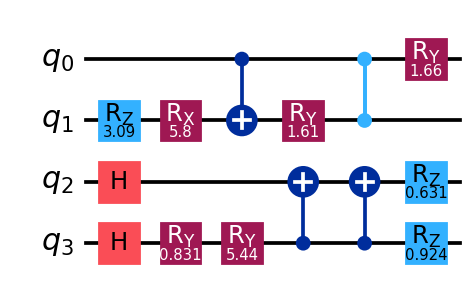


📐 Circuit optimisé (compressé)
   Portes    : {'ry': 4, 'rz': 3, 'h': 2, 'rx': 1, 'cx': 1, 'cz': 1}
   Profondeur: 6


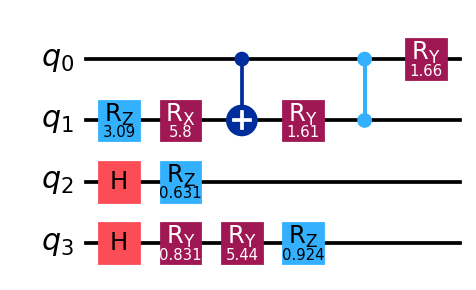

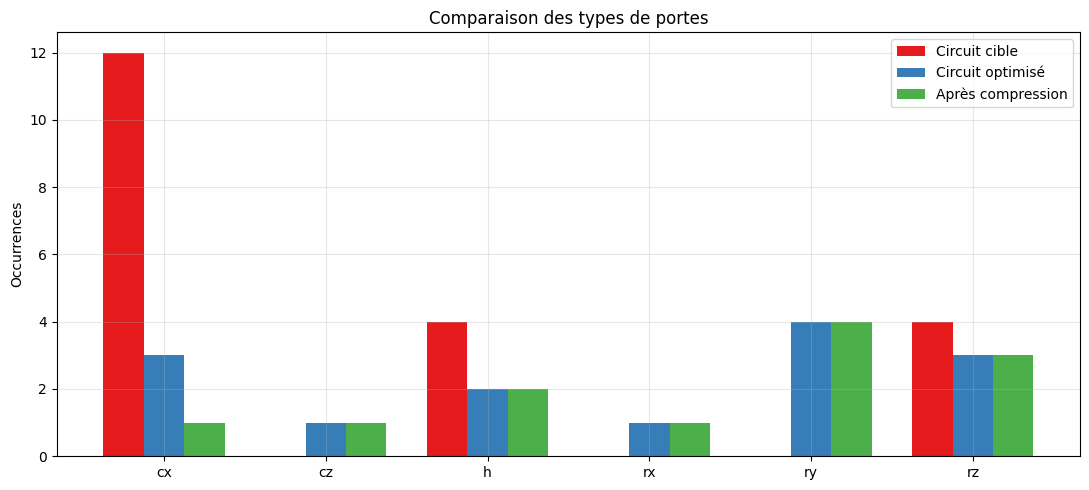

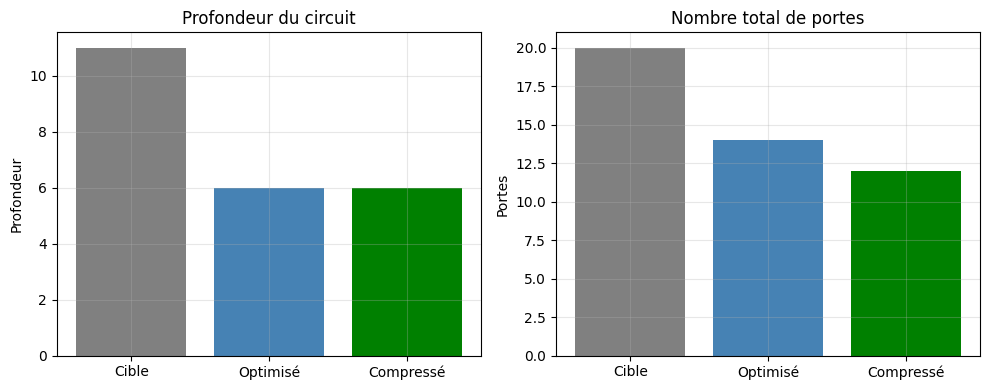

In [28]:
# ============================================================
# 13. Entry point
# ============================================================

if __name__ == "__main__":

    MASTER_SEED = 29
    set_random_seeds(MASTER_SEED)

    num_qubits  = 4
    num_genes   = 10
    pop_size    = 100
    generations = 50

    # ---- circuit cible ----
    target_unitary = create_target_circuit(num_qubits)
    target_qc      = QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        target_qc.h(i)
    for _ in range(4):
        for j in range(num_qubits - 1):
            target_qc.cx(j, j + 1)
    for i in range(num_qubits):
        target_qc.rz((i + 1) * np.pi / 14, i)

    print("\n🚀 Démarrage de l'optimisation mono-objectif améliorée...")
    print(f"   {num_qubits} qubits | {num_genes} gènes | "
          f"{pop_size} individus | {generations} générations")
    print(f"   Gate set : {list(QUANTUM_GATES.keys())}")

    best_ind, best_compressed, history = single_objective_genetic_algorithm(
        num_qubits     = num_qubits,
        num_genes      = num_genes,
        pop_size       = pop_size,
        generations    = generations,
        target_unitary = target_unitary,
        mutation_rate  = 0.1,
        max_mutations  = 2,
        crossover_rate = 0.9,
        elitism_ratio  = 0.1,
        initial_temp   = 1.0,
        cooling_rate   = 0.95,
        stagnation_thr = 20,
        selection_mode = "roulette",    # "roulette" | "rank" | "tournament"
    )

    print(f"\n✅ Optimisation terminée !")
    print(f"   Fidélité finale (brute)      : {best_ind.fitness:.4f}")
    print(f"   Fidélité après compression   : "
          f"{compute_fidelity(best_compressed, target_unitary):.4f}")

    # ---- visualisations ----
    plot_convergence(history)

    best_raw = create_quantum_circuit(best_ind.chromosome, num_qubits)
    plot_best_circuit(best_raw,        "Circuit optimisé (brut)")
    plot_best_circuit(best_compressed, "Circuit optimisé (compressé)")

    plot_gate_comparison(target_qc, best_raw, best_compressed)
    plot_depth_and_gate_count(target_qc, best_raw, best_compressed)